<a href="https://colab.research.google.com/github/Noaman123-sam/deployment/blob/main/Task_NN%26ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score)
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(42)

## Load Poker Hand Dataset

In [ ]:
poker = fetch_openml(data_id=1567, as_frame=True)

X = poker.data
y = poker.target.astype(int)

In [ ]:
print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)



Features Shape: (1025009, 10)
Labels Shape: (1025009,)


#Count Plot

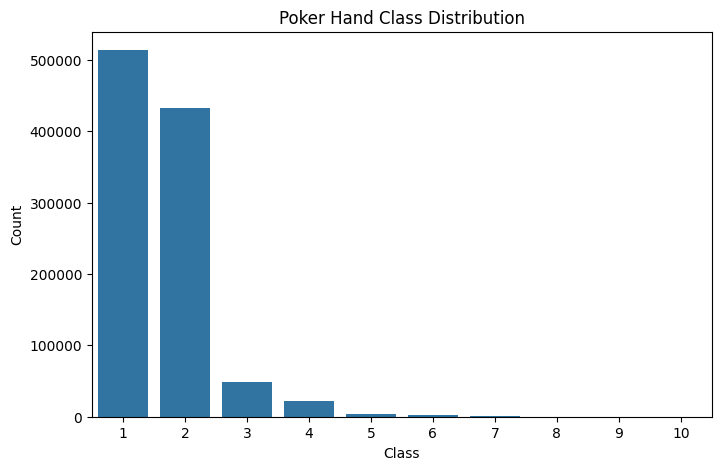

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x=y)

plt.title("Poker Hand Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Scaling


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#change data to tensor

In [ ]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

#check device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


#model build

In [ ]:
class MLP(nn.Module):

    def __init__(self):

        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(10,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,10)

        )

    def forward(self,x):
        return self.network(x)

model = MLP().to(device)
print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=10, bias=True)
  )
)


#Training Setup

In [ ]:



criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 20

train_losses = []
train_accuracies = []

#Training Loop

In [ ]:
y_train = y_train - 1
y_test = y_test - 1

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


if torch.isnan(X_train).any() or torch.isinf(X_train).any():
    raise ValueError("X_train contains NaN or Inf values after preprocessing and tensor conversion.")
if torch.isnan(y_train).any() or torch.isinf(y_train).any():
    raise ValueError("y_train contains NaN or Inf values after preprocessing and tensor conversion.")

num_classes = model.network[-1].out_features
if y_train.min() < 0 or y_train.max() >= num_classes:
    raise ValueError(f"y_train contains labels outside the expected range [0, {num_classes-1}]. Min: {y_train.min()}, Max: {y_train.max()}.")

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}]  Loss = {epoch_loss:.4f}   Accuracy = {epoch_acc:.2f}%")

Epoch [1/20]  Loss = 0.9305   Accuracy = 56.09%
Epoch [2/20]  Loss = 0.8739   Accuracy = 59.24%
Epoch [3/20]  Loss = 0.8413   Accuracy = 61.05%
Epoch [4/20]  Loss = 0.8241   Accuracy = 61.78%
Epoch [5/20]  Loss = 0.8146   Accuracy = 62.12%
Epoch [6/20]  Loss = 0.8065   Accuracy = 62.34%
Epoch [7/20]  Loss = 0.8007   Accuracy = 62.54%
Epoch [8/20]  Loss = 0.7971   Accuracy = 62.63%
Epoch [9/20]  Loss = 0.7930   Accuracy = 62.84%
Epoch [10/20]  Loss = 0.7895   Accuracy = 62.88%
Epoch [11/20]  Loss = 0.7862   Accuracy = 63.04%
Epoch [12/20]  Loss = 0.7853   Accuracy = 63.06%
Epoch [13/20]  Loss = 0.7835   Accuracy = 63.04%
Epoch [14/20]  Loss = 0.7821   Accuracy = 63.07%
Epoch [15/20]  Loss = 0.7806   Accuracy = 63.26%
Epoch [16/20]  Loss = 0.7804   Accuracy = 63.32%
Epoch [17/20]  Loss = 0.7806   Accuracy = 63.23%
Epoch [18/20]  Loss = 0.7792   Accuracy = 63.36%
Epoch [19/20]  Loss = 0.7757   Accuracy = 63.50%
Epoch [20/20]  Loss = 0.7747   Accuracy = 63.55%


#Learning Curves

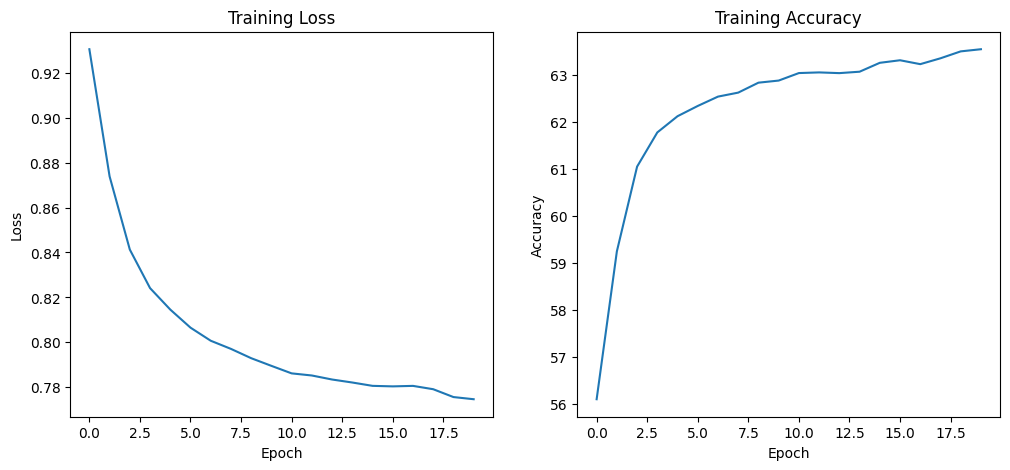

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

#Model Evaluation

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#classification report

In [ ]:
accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy)

print(classification_report(all_labels, all_preds))

Test Accuracy: 0.7269880293850791
              precision    recall  f1-score   support

           0       0.73      0.94      0.82    102740
           1       0.72      0.59      0.65     86619
           2       0.44      0.01      0.02      9766
           3       0.78      0.09      0.16      4327
           4       0.00      0.00      0.00       796
           5       0.99      1.00      0.99       410
           6       0.36      0.02      0.03       292
           7       0.00      0.00      0.00        47
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         2

    accuracy                           0.73    205002
   macro avg       0.40      0.26      0.27    205002
weighted avg       0.71      0.73      0.69    205002



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#confusion matrix

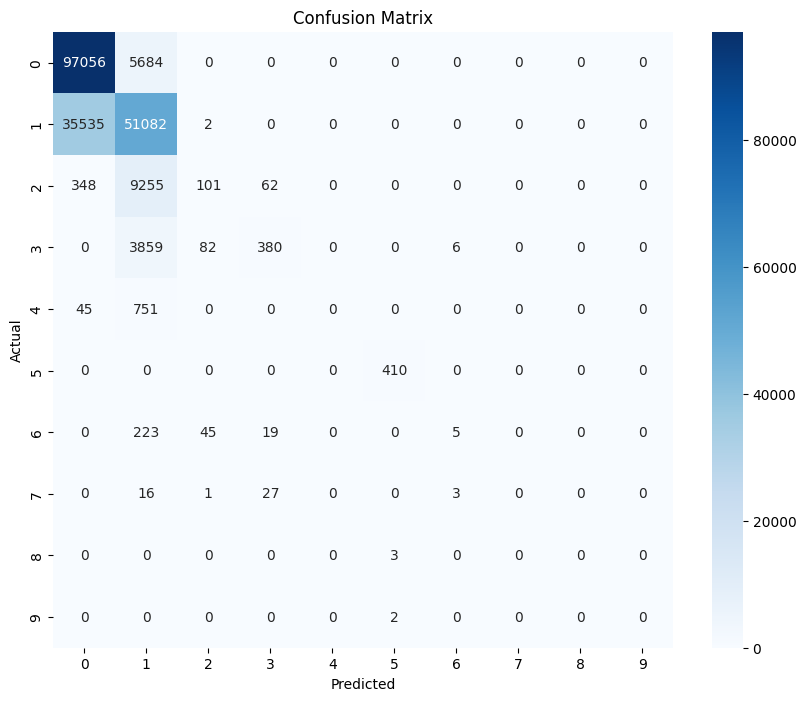

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()